# Flow Matching on 2D Toy Datasets

This notebook implements **Flow Matching** (Lipman et al., 2022).
We test this on three 2D toy distributions and compare different ODE solvers.

## Setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from tqdm.auto import tqdm
import ot 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# seeds
torch.manual_seed(42)
np.random.seed(42)

## Target datasets



In [ ]:
def sample_moons(n, noise=0.05):
    """Sample n points from the two-moons distribution."""
    X, _ = make_moons(n_samples=n, noise=noise)
    return torch.tensor(X, dtype=torch.float32)


def sample_gaussian_mixture(n, n_components=8, radius=3.0, std=0.3):
    """Sample n points from a ring of Gaussian blobs."""
    # place cluster centres
    angles = torch.linspace(0, 2 * np.pi, n_components + 1)[:-1]
    means = radius * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
    # randomly assign each point to a cluster, then add Gaussian noise
    idx = torch.randint(0, n_components, (n,))
    return means[idx] + std * torch.randn(n, 2)


def sample_checkerboard(n, size=4):
    """Sample n points from a checkerboard pattern."""
    samples = []
    while len(samples) < n:
        # generate random points in a grid
        x = torch.rand(n * 4, 2) * size - size / 2
        ix = torch.floor(x[:, 0]).long()
        iy = torch.floor(x[:, 1]).long()
        samples.append(x[(ix + iy) % 2 == 0])
    return torch.cat(samples)[:n]

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="white")
datasets = [
    ("8 Gaussians", sample_gaussian_mixture(4000)),
    ("Two Moons", sample_moons(4000)),
    ("Checkerboard", sample_checkerboard(4000)),
]
for ax, (name, data) in zip(axes, datasets):
    ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.5)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

## Velocity network

A small MLP that takes a 2D point **x** and a scalar time **t**, and outputs a 2D velocity.
This is the function we train to approximate the velocity field.

In [ ]:
class VelocityMLP(nn.Module):

    def __init__(self, data_dim=2, hidden_dim=256, n_layers=4):
        super().__init__()
        # first layer takes [x, t] 
        layers = [nn.Linear(data_dim + 1, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        return self.net(torch.cat([x, t], dim=-1))

## Training loop

We define a straight-line path from each noise sample
$x_0$ to each data sample $x_1$. At a random time $t$, the interpolated point is
$x_t = (1-t)\,x_0 + t\,x_1$, and the ground-truth velocity along this path is simply
$x_1 - x_0$. We train the network to predict that velocity.

In [ ]:
def train_flow_matching(model, sample_data_fn, n_steps=15_000, batch_size=512, lr=1e-3):
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    pbar = tqdm(range(n_steps), desc="Training")
    for step in pbar:
        # x1 = real data samples, x0 = noise
        x1 = sample_data_fn(batch_size).to(device)
        x0 = torch.randn_like(x1)

        # pick t in [0,1]
        t = torch.rand(batch_size, device=device)

        # interpolate along the straight line from noise to data
        t_ = t.unsqueeze(-1)          
        xt = (1 - t_) * x0 + t_ * x1  # position at time t

        target = x1 - x0

        pred = model(xt, t)
        loss = (pred - target).pow(2).mean()

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        losses.append(loss.item())
        if step % 500 == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    return losses

## Generation

To generate samples we start from pure noise at $t=0$ and integrate the learned velocity
field forward to $t=1$. We implement three solvers of increasing order:
- **Euler** 
- **Midpoint** 
- **RK4** 

In [ ]:
@torch.no_grad()
def generate(model, n_samples=1000, n_steps=100, method="midpoint", return_trajectories=False):
    """Integrate the learned velocity field from t=0 to t=1."""
    model.eval()
    dt = 1.0 / n_steps
    x = torch.randn(n_samples, 2, device=device)  # start from pure noise

    if return_trajectories:
        trajectory = [x.cpu().clone()]

    for i in range(n_steps):
        t = i * dt
        t_tensor = torch.full((n_samples,), t, device=device)

        if method == "euler":
            v = model(x, t_tensor)
            x = x + dt * v

        elif method == "midpoint":
            v = model(x, t_tensor)
            x_mid = x + (dt / 2) * v
            t_mid = torch.full((n_samples,), t + dt / 2, device=device)
            v_mid = model(x_mid, t_mid)
            x = x + dt * v_mid

        elif method == "rk4":
            t_half = torch.full((n_samples,), t + dt / 2, device=device)
            t_end = torch.full((n_samples,), t + dt, device=device)
            k1 = model(x, t_tensor)
            k2 = model(x + (dt / 2) * k1, t_half)
            k3 = model(x + (dt / 2) * k2, t_half)
            k4 = model(x + dt * k3, t_end)
            x = x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

        if return_trajectories:
            trajectory.append(x.cpu().clone())

    model.train()
    if return_trajectories:
        return x.cpu(), torch.stack(trajectory, dim=1)
    return x.cpu()

## Evaluation metric

We measure sample quality using the **Wasserstein-2** ($W_2$) distance between generated
and true samples. Lower = better. 

In [ ]:
def compute_w2(generated, reference):
    """Wasserstein-2 distance."""
    n, m = len(generated), len(reference)

    a = np.ones(n) / n
    b = np.ones(m) / m

    C = ot.dist(generated, reference, metric="sqeuclidean")
    # solve optimal transport and return the W2 distance
    return np.sqrt(ot.emd2(a, b, C))

## Plotting helpers

In [ ]:
def plot_progression(trajectories, n_steps, times, xlim, ylim, title=None):
    """Show snapshots of the sample distribution at several time steps."""
    fig, axes = plt.subplots(1, len(times), figsize=(4.0 * len(times), 4.0), facecolor="white")
    for ax, t in zip(np.atleast_1d(axes), times):
        step_idx = min(int(round(t * n_steps)), trajectories.shape[1] - 1)
        pts = trajectories[:, step_idx].numpy()
        ax.scatter(pts[:, 0], pts[:, 1], s=2.0, alpha=0.4, linewidths=0)
        ax.set_title(f"t = {t:.2f}", fontsize=12)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_paths(trajectories, n_paths=150):
    """Draw individual sample."""
    traj = trajectories.numpy() if hasattr(trajectories, "numpy") else np.asarray(trajectories)
    idx = np.linspace(0, traj.shape[0] - 1, n_paths).astype(int)

    fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
    # thin grey lines showing each sample's path through time
    for i in idx:
        ax.plot(traj[i, :, 0], traj[i, :, 1], lw=0.8, alpha=0.12, color="#8A8A8A")
    # dots at the start (noise) and end (data)
    ax.scatter(traj[idx, 0, 0], traj[idx, 0, 1], s=14, alpha=0.9, color="#0072B2", label="t = 0 (noise)")
    ax.scatter(traj[idx, -1, 0], traj[idx, -1, 1], s=14, alpha=0.9, color="#D55E00", label="t = 1 (data)")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

## Experiment 1 — Flow matching progression

Train on **8 Gaussians** and **Two Moons** (15k steps each), then visualise how the
generated distribution evolves from noise to data as we integrate from $t=0$ to $t=1$.

In [ ]:
# train on the 8-Gaussians dataset
model_8g = VelocityMLP().to(device)
losses_8g = train_flow_matching(
    model_8g,
    sample_data_fn=lambda n: sample_gaussian_mixture(n),
    n_steps=15_000,
)

In [ ]:
# generate 4000 samples and save the full trajectory so we can plot snapshots
_, traj_8g = generate(model_8g, n_samples=4000, n_steps=250, method="midpoint", return_trajectories=True)
plot_progression(traj_8g, 250, np.linspace(0, 1, 5), xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))

In [ ]:
# train on the two-moons dataset
model_moons = VelocityMLP().to(device)
losses_moons = train_flow_matching(
    model_moons,
    sample_data_fn=lambda n: sample_moons(n, noise=0.05),
    n_steps=15_000,
)

In [ ]:
# same thing for two moons
_, traj_moons = generate(model_moons, n_samples=4000, n_steps=250, method="midpoint", return_trajectories=True)
plot_progression(traj_moons, 250, np.linspace(0, 1, 5), xlim=(-2.2, 3.2), ylim=(-1.6, 2.1))

## Sample paths


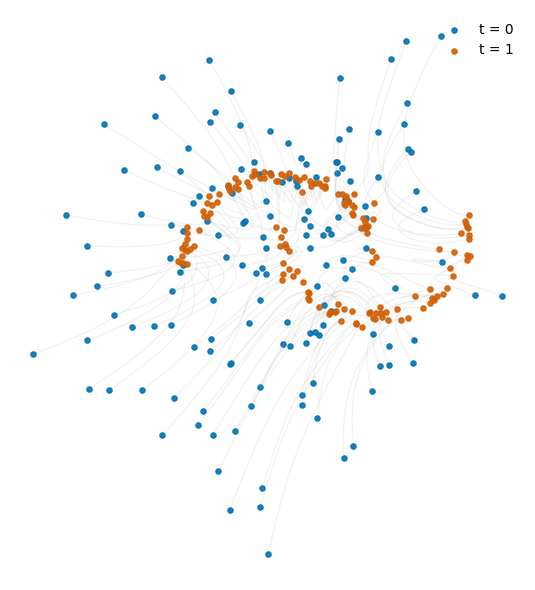

In [18]:
plot_paths(traj_moons, n_paths=150)

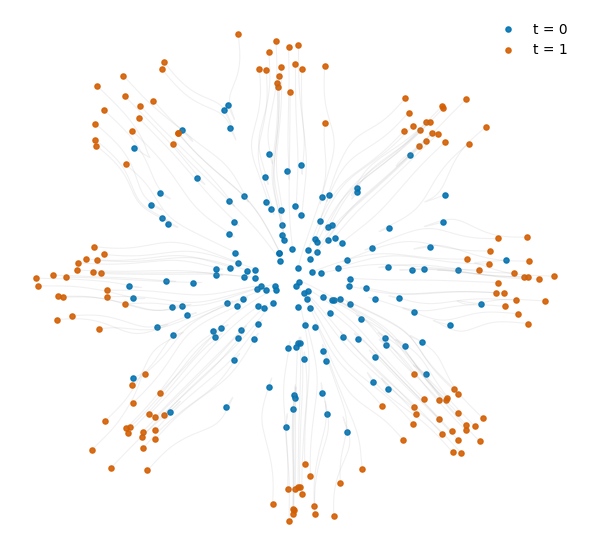

In [19]:
plot_paths(traj_8g, n_paths=150)

## Experiment 2 — ODE solver comparison

We deliberately train on the **Checkerboard** for only **5k steps** (under-trained) so
the differences between solvers are more visible. Then we generate 4k samples with each
solver using 1–25 integration steps and measure $W_2$ to a reference set.

In [ ]:
# train on checkerboard 
model_cb = VelocityMLP().to(device)
losses_cb = train_flow_matching(
    model_cb,
    sample_data_fn=sample_checkerboard,
    n_steps=5_000,
)

In [ ]:

torch.manual_seed(0)
reference_cb = sample_checkerboard(4_000).numpy()

torch.manual_seed(123)
ref2_cb = sample_checkerboard(4_000).numpy()
print(f"Baseline W2 (true vs true): {compute_w2(ref2_cb, reference_cb):.4f}")

# sweep over solvers and step counts
solvers = ["euler", "midpoint", "rk4"]
step_counts = [1, 2, 3, 5, 10, 25]

results_cb = {s: [] for s in solvers}
for method in solvers:
    for n_steps in step_counts:
        torch.manual_seed(0)  
        samples = generate(model_cb, n_samples=4000, n_steps=n_steps, method=method)
        w2 = compute_w2(samples.numpy(), reference_cb)
        results_cb[method].append(w2)
        print(f"{method:>10s}  steps={n_steps:>4d}  W2={w2:.4f}")

In [ ]:
# plot W2 vs number of integration steps for each solver
colors = {"euler": "#D55E00", "midpoint": "#0072B2", "rk4": "#009E73"}

fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
for method in solvers:
    ax.plot(step_counts, results_cb[method], "o-", color=colors[method],
            label=method.capitalize(), markersize=5)

ax.set_xlabel("Number of steps")
ax.set_ylabel("$W_2$")
ax.set_xscale("log")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()